In [3]:
pip install opencv-python

   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   -- ------------------------------------- 2.6/38.8 MB 21.6 MB/s eta 0:00:02
   ------- -------------------------------- 7.6/38.8 MB 23.5 MB/s eta 0:00:02
   ----------- ---------------------------- 11.0/38.8 MB 20.9 MB/s eta 0:00:02
   --------------- ------------------------ 15.2/38.8 MB 20.8 MB/s eta 0:00:02
   ------------------- -------------------- 18.6/38.8 MB 19.6 MB/s eta 0:00:02
   -------------------- ------------------- 19.9/38.8 MB 17.2 MB/s eta 0:00:02
   -------------------------- ------------- 26.0/38.8 MB 18.7 MB/s eta 0:00:01
   --------------------------------- ------ 32.5/38.8 MB 20.8 MB/s eta 0:00:01
   ---------------------------------------  38.8/38.8 MB 21.8 MB/s eta 0:00:01
   ---------------------------------------- 38.8/38.8 MB 21.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Segment 1: Importing necessary libraries
# In this segment, we import all the required libraries for data processing, model building, and training.
# It's a good practice to import everything at once to keep track of dependencies.

import os  # For file and directory handling
import pandas as pd  # For data manipulation and analysis
import tensorflow
import numpy as np  # For array manipulations
import cv2  # OpenCV for image loading and preprocessing
from sklearn.preprocessing import LabelEncoder  # For encoding categorical labels
from sklearn.model_selection import train_test_split  # For splitting the dataset
from keras.models import Sequential  # For building the CNN model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN layers
from keras.optimizers import Adam  # Optimizer for model training
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For data augmentation
from keras.callbacks import ModelCheckpoint,EarlyStopping  # For early stopping during training
from sklearn.metrics import classification_report  # For generating classification metrics
import matplotlib.pyplot as plt  # For visualizations and plots 
import tkinter as tk
from tkinter import filedialog, Label
from PIL import Image, ImageTk
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
print("All necessary libraries imported successfully.")


All necessary libraries imported successfully.


In [5]:


def load_images_from_folder(folder, label):
    """
    Load images from a specified folder and assign a label to each image.

    Args:
        folder (str): Path to the folder containing images.
        label (int): Label to assign to the images (0 for no tumor, 1 for with tumor).

    Returns:
        np.ndarray: Array of images.
        np.ndarray: Array of corresponding labels.
    """
    images = []
    labels = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))  # Load the image
        if img is not None:
            img = cv2.resize(img, (224, 224))  # Resize the image to the desired dimensions
            images.append(img)  # Append the image to the list
            labels.append(label)  # Append the corresponding label (0 or 1)
    return np.array(images), np.array(labels)  # Return the images and labels as numpy arrays

# Load images and labels from the folder with tumors
X_tumor, y_tumor = load_images_from_folder(r'C:\Users\karth\PROJECTS\braintumor\BrainTumor\yes', label=1)  # Label 1 for with tumor

# Load images and labels from the folder without tumors
X_no_tumor, y_no_tumor = load_images_from_folder(r'C:\Users\karth\PROJECTS\braintumor\BrainTumor\no', label=0)  # Label 0 for no tumor

# Combine the images and labels from both folders
X = np.concatenate((X_tumor, X_no_tumor))  # Combine all images
y = np.concatenate((y_tumor, y_no_tumor))  # Combine all labels

# Print the results
print(f"Loaded {X.shape[0]} images.")
print(f"Labels: {y}")
print(len(y))


Loaded 253 images.
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
253


In [6]:
# This segment splits the loaded images and labels into training, validation, and testing sets.
# The split ratios will be defined for each set to ensure proper model evaluation.

# Define the split ratios
train_ratio = 0.7  # 70% for training
val_ratio = 0.15   # 15% for validation
test_ratio = 0.15  # 15% for testing

# Check that the sum of ratios is equal to 1
assert (train_ratio + val_ratio + test_ratio) == 1.0, "The ratios must sum to 1."

# Split the dataset into training and temporary (validation + test) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_ratio, random_state=42)

# Split the temporary set into validation and test sets
# Since val_ratio + test_ratio = 0.3, the split will correctly allocate 15% to each.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_ratio/(val_ratio + test_ratio), random_state=42)

# Print the shapes of the resulting datasets
print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")  # Training set
print(f"Validation data shape: {X_val.shape}, Labels shape: {y_val.shape}")  # Validation set
print(f"Test data shape: {X_test.shape}, Labels shape: {y_test.shape}")  # Test set

Training data shape: (177, 224, 224, 3), Labels shape: (177,)
Validation data shape: (38, 224, 224, 3), Labels shape: (38,)
Test data shape: (38, 224, 224, 3), Labels shape: (38,)


In [7]:
 # X: loaded images, y: loaded labels
# Assuming images and labels are numpy arrays from previous steps
# Use X and y to represent images and labels here

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Check the shape of the training and testing datasets
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training data shape: (177, 224, 224, 3)
Testing data shape: (76, 224, 224, 3)
Training labels shape: (177,)
Testing labels shape: (76,)


In [8]:
## Segment 4: Data Augmentation
## This segment uses ImageDataGenerator to apply various transformations to the training data.
## This helps improve the model's ability to generalize.
#
## Creating an instance of ImageDataGenerator for data augmentation
#train_datagen = ImageDataGenerator(
#    rotation_range=20,       # Randomly rotate images in the range (degrees)
#    width_shift_range=0.2,   # Randomly shift images horizontally (20% of total width)
#    height_shift_range=0.2,  # Randomly shift images vertically (20% of total height)
#    shear_range=0.2,        # Shear angle in counter-clockwise direction in degrees
#    zoom_range=0.2,         # Randomly zoom into images
#    horizontal_flip=True,    # Randomly flip images horizontally
#    fill_mode='nearest'      # Fill pixels that are newly created after a transformation
#)
#
## Fitting the data generator to the training data
#train_datagen.fit(X_train)
#
## Print confirmation
#print("Data augmentation setup complete.")


In [9]:
# Segment 5: Building the VGG16 Model from Scratch
# This segment defines the VGG16 architecture manually using Keras
# for the classification of brain tumor images.


# Initialize the VGG16 model
model = Sequential()

# Block 1
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)))  # First convolution layer
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # Second convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # First max pooling layer

# Block 2
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))  # First convolution layer
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))  # Second convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Second max pooling layer

# Block 3
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))  # First convolution layer
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))  # Second convolution layer
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))  # Third convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Third max pooling layer

# Block 4
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))  # First convolution layer
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))  # Second convolution layer
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))  # Third convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Fourth max pooling layer

# Block 5
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))  # First convolution layer
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))  # Second convolution layer
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))  # Third convolution layer
model.add(MaxPooling2D(pool_size=(2, 2)))  # Fifth max pooling layer

# Fully Connected Layers
model.add(Flatten())  # Flattening the output from the convolutional blocks
model.add(Dense(4096, activation='relu'))  # First fully connected layer
model.add(Dropout(0.5))  # Dropout layer for regularization
model.add(Dense(4096, activation='relu'))  # Second fully connected layer
model.add(Dropout(0.5))  # Dropout layer for regularization
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 134,264,641 (512.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5820 - loss: 5744.4238 - val_accuracy: 0.6875 - val_loss: 1.2315
Epoch 2/50
1/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6250 - loss: 1.7114

c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6250 - loss: 1.7114 - val_accuracy: 0.3333 - val_loss: 0.8764
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.3688 - loss: 0.7516
Epoch 4/50


c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:206: UserWarning: Can save best model only with val_accuracy available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)
c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.6562 - loss: 0.6895 - val_accuracy: 0.6875 - val_loss: 0.6862
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.6274 - loss: 0.6817 - val_accuracy: 0.6667 - val_loss: 0.6358
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6471 - loss: 0.6296
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6205 - loss: 0.6439 - val_accuracy: 0.5625 - val_loss: 0.6886
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5625 - loss: 0.6818 - val_accuracy: 0.6667 - val_loss: 0.6782
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.6247 - loss: 0.6767
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.5294 - loss: 0.6723 - val_accuracy: 0.6562 - val_loss: 0.6182
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.4979 - loss: 0.6790 - val_accuracy: 0.8333 - val_loss: 0.5536
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6250 - loss: 0.6494
Epoch 13/50
5

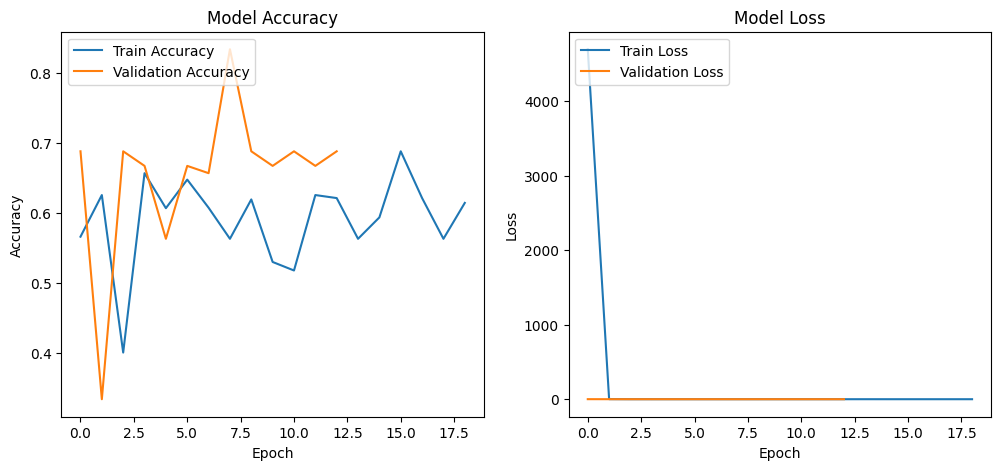

In [10]:

# Assume 'X_train', 'X_val', 'X_test', 'y_train', 'y_val', and 'y_test' are already defined

# No data augmentation
train_generator = ImageDataGenerator().flow(X_train, y_train, batch_size=32)
val_generator = ImageDataGenerator().flow(X_val, y_val, batch_size=32)
test_generator = ImageDataGenerator().flow(X_test, y_test, batch_size=32, shuffle=False)

# Define callbacks
checkpoint = ModelCheckpoint('vgg16_model_best.keras', save_best_only=True, monitor='val_accuracy', mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=len(X_train) // 32,
    validation_steps=len(X_val) // 32,
    epochs=50,
    callbacks=[checkpoint, early_stopping]
)

# Plot training and validation accuracy and loss
import matplotlib.pyplot as plt

# Plotting training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plotting training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.show()


In [11]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")



3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 606ms/step - accuracy: 0.6100 - loss: 0.6554
Test Accuracy: 61.84%
Test Loss: 0.6488


In [12]:
# Save the final model
model.save('vgg16_model_final.keras')


In [13]:
def predict(image_path):
    processed_image = preprocess_image(image_path)  # Preprocess single image
    prediction = model.predict(processed_image)     # Predict on the processed image
    predicted_class = (prediction > 0.5).astype("int32")  # Convert probabilities to binary class (0 or 1)
    print(f'Prediction: {predicted_class}')
# Predict using the model on the test set (batch of images)
predictions = model.predict(test_generator)

# Convert predicted probabilities to binary output (0 or 1)
predicted_classes = (predictions > 0.5).astype("int32")



3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 619ms/step


In [14]:


# Get true labels from y_test
true_classes = y_test  # Since y_test contains your true labels

# Convert predictions to binary values
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype("int32")

# Confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Classification report
class_report = classification_report(true_classes, predicted_classes)
print("Classification Report:")
print(class_report)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 589ms/step
Confusion Matrix:
[[ 0 29]
 [ 0 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.62      1.00      0.76        47

    accuracy                           0.62        76
   macro avg       0.31      0.50      0.38        76
weighted avg       0.38      0.62      0.47        76



c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [17]:
import tkinter as tk
from tkinter import Label, filedialog
from PIL import Image, ImageTk
import numpy as np
from keras.models import load_model

# Load your trained model
model = load_model('vgg16_model_best.keras')
IMAGE_SIZE = (224, 224)

# Function to preprocess the uploaded image
def preprocess_image(image):
    image = image.convert("RGB")  # Ensure image has 3 channels (RGB)
    img = image.resize(IMAGE_SIZE)  # Resize the image
    img = np.array(img) / 255.0     # Normalize the image
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Function to make a prediction
def predict(image_path):
    image = Image.open(image_path)
    processed_image = preprocess_image(image)
    prediction = model.predict(processed_image)

    result = "Brain rot" if prediction[0][0] > 0.5 else "No Tumor"
    result_label.config(text="Result: " + result)

# Function to open a file dialog and load image
def open_image():
    file_path = filedialog.askopenfilename()
    if file_path:
        img = Image.open(file_path)
        img = img.resize((250, 250))  # Resize image for display
        img_tk = ImageTk.PhotoImage(img)

        image_label.config(image=img_tk)
        image_label.image = img_tk  # Keep a reference to avoid garbage collection

        predict(file_path)  # Make prediction on selected image

# Create the main application window
window = tk.Tk()
window.title("Brain Tumor Detection")
window.geometry("400x500")

# Add components
image_label = Label(window)
image_label.pack(pady=20)

button = tk.Button(window, text="Upload MRI Image", command=open_image)
button.pack(pady=20)

result_label = Label(window, text="Result: ", font=("Helvetica", 16))
result_label.pack(pady=20)

# Start the Tkinter event loop
window.mainloop()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
